In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np
from pathlib import Path
from scipy.ndimage import uniform_filter1d

In [2]:
BASE = Path('../runs/poster')
runs = {
    'M = 16':  BASE / 'm16'  / 'train_log.csv',
    'M = 64':  BASE / 'm64'  / 'train_log.csv',
    'M = 256': BASE / 'm256' / 'train_log.csv',
}
dfs = {label: pd.read_csv(path) for label, path in runs.items()}

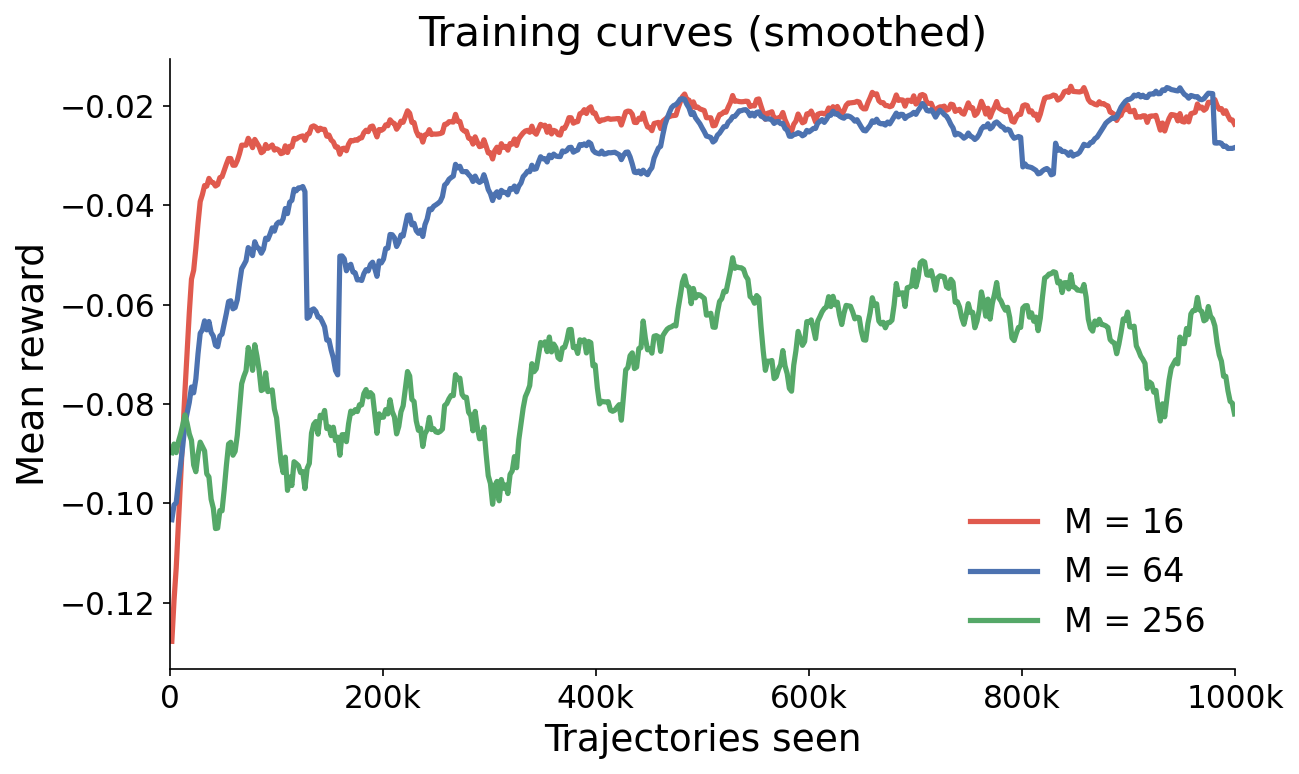

Saved to ../outputs/poster_figures/


In [3]:
# ── Poster style ────────────────────────────────────────────────────────────
plt.rcParams.update({
    'font.family':       'sans-serif',
    'font.size':         18,
    'axes.titlesize':    20,
    'axes.labelsize':    18,
    'xtick.labelsize':   15,
    'ytick.labelsize':   15,
    'legend.fontsize':   16,
    'lines.linewidth':   2.5,
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'figure.dpi':        150,
})

COLORS     = ['#E05A4E', '#4C72B0', '#55A868']   # red, blue, green
SMOOTH     = 15           # uniform-filter window (steps)
TOTAL_TRAJ = 1_000_000   # x-axis upper limit (trajectories seen)

OUT = Path('../outputs/poster_figures')
OUT.mkdir(parents=True, exist_ok=True)


def smooth(x, w=SMOOTH):
    return uniform_filter1d(x, size=w, mode='nearest')


fig, ax = plt.subplots(figsize=(9, 5.5))

for (label, df), color in zip(dfs.items(), COLORS):
    # traj column = step * batch_size, already in the log
    df = df[df['traj'] <= TOTAL_TRAJ]
    traj   = df['traj'].values
    r_mean = df['reward_mean'].values
    r_std  = df['reward_std'].values

    s_mean = smooth(r_mean)
    s_std  = smooth(r_std)

    ax.plot(traj, s_mean, color=color, label=label)
    # ax.fill_between(traj, s_mean - s_std, s_mean + s_std,
    #                 color=color, alpha=0.18, linewidth=0)

ax.set_xlabel('Trajectories seen')
ax.set_ylabel('Mean reward')
ax.set_title('Training curves (smoothed)')
ax.set_xlim(0, TOTAL_TRAJ)
ax.legend(frameon=False)
ax.xaxis.set_major_formatter(ticker.FuncFormatter(
    lambda x, _: f'{int(x/1000)}k' if x > 0 else '0'
))

fig.tight_layout()
fig.savefig(OUT / 'poster_training_curves.pdf', bbox_inches='tight')
fig.savefig(OUT / 'poster_training_curves.png', bbox_inches='tight', dpi=300)
plt.show()
print(f'Saved to {OUT}/')

[-0.157964   -0.141114   -0.0656903  -0.100705   -0.085018   -0.0737914
 -0.0335994  -0.0509727  -0.0319053  -0.0514829  -0.0231795  -0.0261449
 -0.0250062  -0.019554   -0.0355213  -0.0342975  -0.0332095  -0.0322934
 -0.0311725  -0.0157391  -0.0152213  -0.0148548  -0.0293161  -0.0342018
 -0.0336075  -0.0335022  -0.0279466  -0.0324138  -0.0169171  -0.0165116
 -0.0315017  -0.0157559  -0.0159707  -0.0155195  -0.0151557  -0.0304832
 -0.014724   -0.0147049  -0.0141959  -0.0107579  -0.0299309  -0.0244865
 -0.0136248  -0.0245962  -0.0293668  -0.0100839  -0.0241171  -0.0239867
 -0.029374   -0.0098189  -0.0130006  -0.0236766  -0.009577   -0.00951604
 -0.0233804  -0.0287061  -0.0283565  -0.0232685  -0.0234003  -0.01256
 -0.0287773  -0.00888891 -0.027877   -0.00875316 -0.012317   -0.00860348
 -0.0227336  -0.00856086 -0.0226119  -0.00813999 -0.0281117  -0.0123065
 -0.02305    -0.0282897  -0.0226914  -0.0224866  -0.0120496  -0.027563
 -0.027621   -0.00771665 -0.0220582  -0.0275026  -0.0218207  -0.0

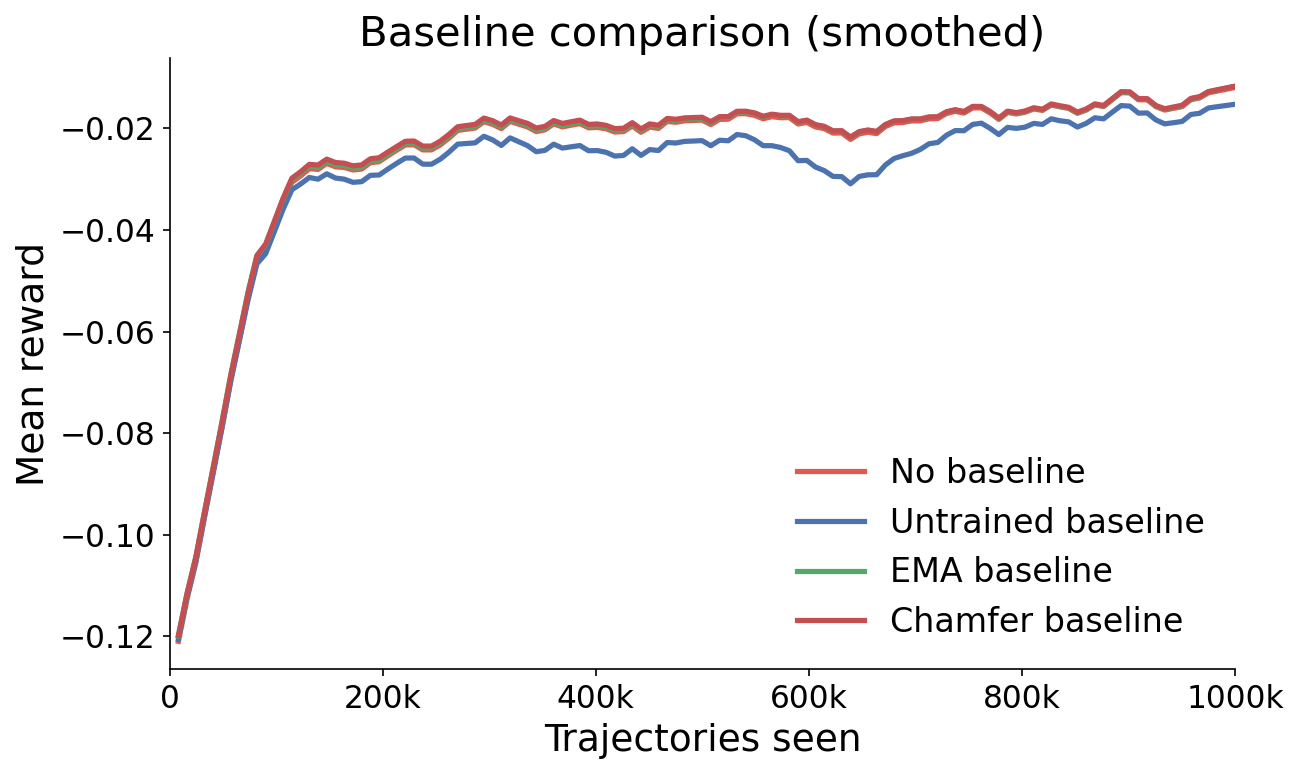

Saved to ../outputs/poster_figures/


In [4]:
baseline_runs = {
    'No baseline':        BASE / 'baseline_none'       / 'train_log.csv',
    'Untrained baseline': BASE / 'baseline_randominit' / 'train_log.csv',
    'EMA baseline':       BASE / 'baseline_ema'        / 'train_log.csv',
    'Chamfer baseline':   BASE / 'baseline_chamfer'    / 'train_log.csv',
}
baseline_dfs = {label: pd.read_csv(path) for label, path in baseline_runs.items()}

BASELINE_COLORS = ['#E05A4E', '#4C72B0', '#55A868', '#C44E52']

fig, ax = plt.subplots(figsize=(9, 5.5))

for (label, df), color in zip(baseline_dfs.items(), BASELINE_COLORS):
    df = df[df['traj'] <= TOTAL_TRAJ]
    traj   = df['traj'].values
    r_mean = df['reward_mean'].values
    r_std  = df['reward_std'].values

    print(r_mean)
    s_mean = smooth(r_mean)
    s_std  = smooth(r_std)

    ax.plot(traj, s_mean, color=color, label=label)

ax.set_xlabel('Trajectories seen')
ax.set_ylabel('Mean reward')
ax.set_title('Baseline comparison (smoothed)')
ax.set_xlim(0, TOTAL_TRAJ)
ax.legend(frameon=False)
ax.xaxis.set_major_formatter(ticker.FuncFormatter(
    lambda x, _: f'{int(x/1000)}k' if x > 0 else '0'
))

fig.tight_layout()
fig.savefig(OUT / 'poster_baseline_curves.pdf', bbox_inches='tight')
fig.savefig(OUT / 'poster_baseline_curves.png', bbox_inches='tight', dpi=300)
plt.show()
print(f'Saved to {OUT}/')

[-0.0953428 -0.107607  -0.0573075 -0.110813  -0.109906  -0.108467
 -0.0524839 -0.0955    -0.0582468 -0.131922  -0.048792  -0.0523642
 -0.0495466 -0.0446947 -0.0840525 -0.0827598 -0.0821859 -0.0808728
 -0.088844  -0.0389861 -0.0385786 -0.0389331 -0.0700177 -0.0851732
 -0.0799327 -0.0827437 -0.067861  -0.0785893 -0.0388879 -0.0376565
 -0.0786307 -0.0371595 -0.0380977 -0.0377646 -0.0349435 -0.0778041
 -0.0346318 -0.0361285 -0.034765  -0.030786  -0.0787    -0.0639073
 -0.0355    -0.0629935 -0.0726202 -0.0296889 -0.0581967 -0.0578857
 -0.0657087 -0.0268546 -0.0314742 -0.0498068 -0.0266344 -0.0250378
 -0.047706  -0.0558219 -0.0571615 -0.0454263 -0.0459299 -0.0291306
 -0.0589169 -0.0230481 -0.0520504 -0.0275332 -0.0304208 -0.0915434
 -0.0499539 -0.0304033 -0.061811  -0.0343131 -0.0821981 -0.0487692
 -0.0764081 -0.0908888 -0.0778568 -0.0752354 -0.0550876 -0.0944562
 -0.0863998 -0.0439235 -0.0712667 -0.0851196 -0.0714463 -0.0725965
 -0.0866684 -0.0505468 -0.0405061 -0.0745435 -0.0409559 -0.0482

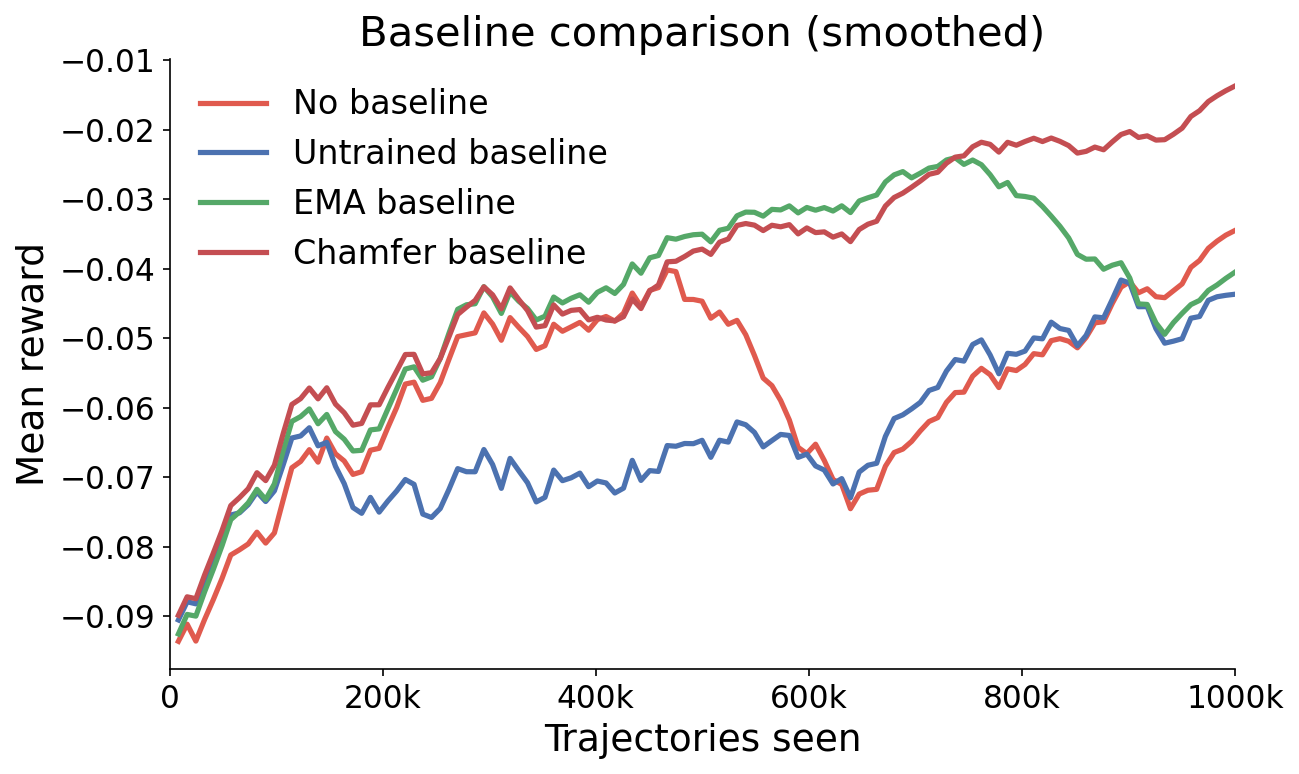

Saved to ../outputs/poster_figures/


In [5]:
baseline_runs = {
    'No baseline':        BASE / 'baseline_none_128'       / 'train_log.csv',
    'Untrained baseline': BASE / 'baseline_prior_128' / 'train_log.csv',
    'EMA baseline':       BASE / 'baseline_ema_128'        / 'train_log.csv',
    'Chamfer baseline':   BASE / 'baseline_chamfer_128'    / 'train_log.csv',
}
baseline_dfs = {label: pd.read_csv(path) for label, path in baseline_runs.items()}

BASELINE_COLORS = ['#E05A4E', '#4C72B0', '#55A868', '#C44E52']

fig, ax = plt.subplots(figsize=(9, 5.5))

for (label, df), color in zip(baseline_dfs.items(), BASELINE_COLORS):
    df = df[df['traj'] <= TOTAL_TRAJ]
    traj   = df['traj'].values
    r_mean = df['reward_mean'].values
    r_std  = df['reward_std'].values

    print(r_mean)
    s_mean = smooth(r_mean)
    s_std  = smooth(r_std)

    ax.plot(traj, s_mean, color=color, label=label)

ax.set_xlabel('Trajectories seen')
ax.set_ylabel('Mean reward')
ax.set_title('Baseline comparison (smoothed)')
ax.set_xlim(0, TOTAL_TRAJ)
ax.legend(frameon=False)
ax.xaxis.set_major_formatter(ticker.FuncFormatter(
    lambda x, _: f'{int(x/1000)}k' if x > 0 else '0'
))

fig.tight_layout()
fig.savefig(OUT / 'poster_baseline_curves.pdf', bbox_inches='tight')
fig.savefig(OUT / 'poster_baseline_curves.png', bbox_inches='tight', dpi=300)
plt.show()
print(f'Saved to {OUT}/')

(610, 11)
(610, 11)
(610, 11)
(610, 11)


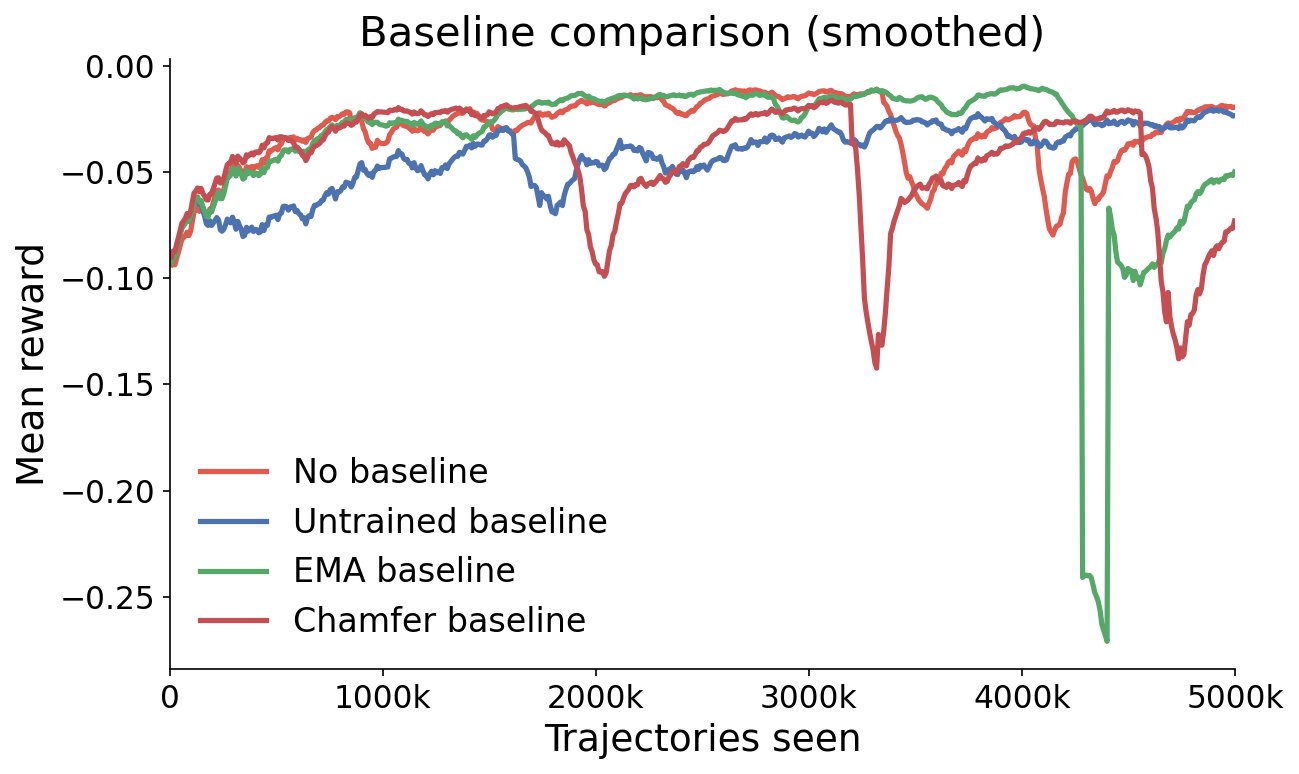

Saved to ../outputs/poster_figures/


In [8]:
TOTAL_TRAJ = 5_000_000
baseline_runs = {
    'No baseline':        BASE / 'baseline_none_128'       / 'train_log.csv',
    'Untrained baseline': BASE / 'baseline_prior_128' / 'train_log.csv',
    'EMA baseline':       BASE / 'baseline_ema_128'        / 'train_log.csv',
    'Chamfer baseline':   BASE / 'baseline_chamfer_128'    / 'train_log.csv',
}
baseline_dfs = {label: pd.read_csv(path) for label, path in baseline_runs.items()}

BASELINE_COLORS = ['#E05A4E', '#4C72B0', '#55A868', '#C44E52']

fig, ax = plt.subplots(figsize=(9, 5.5))

for (label, df), color in zip(baseline_dfs.items(), BASELINE_COLORS):
    df = df[df['traj'] <= TOTAL_TRAJ]
    traj   = df['traj'].values
    r_mean = df['reward_mean'].values
    r_std  = df['reward_std'].values

    print(df.shape)
    s_mean = smooth(r_mean)
    s_std  = smooth(r_std)

    ax.plot(traj, s_mean, color=color, label=label)

ax.set_xlabel('Trajectories seen')
ax.set_ylabel('Mean reward')
ax.set_title('Baseline comparison (smoothed)')
ax.set_xlim(0, TOTAL_TRAJ)
ax.legend(frameon=False)
ax.xaxis.set_major_formatter(ticker.FuncFormatter(
    lambda x, _: f'{int(x/1000)}k' if x > 0 else '0'
))

fig.tight_layout()
fig.savefig(OUT / 'poster_baseline_curves.pdf', bbox_inches='tight')
fig.savefig(OUT / 'poster_baseline_curves.png', bbox_inches='tight', dpi=300)
plt.show()
print(f'Saved to {OUT}/')